In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import numpy as np
import os
from pathlib import Path

plt.rc('font', family='Arial',size=8)


In [2]:
directory = r"./Luis Data/bands_SHU_chi_0.37_eps_45"

for dirpath, dirnames, filenames in os.walk(directory):
    for filename in filenames:
        print(filename)
        if filename.endswith(".txt") or filename.endswith(".out"):
            file_path = os.path.join(dirpath, filename)
            csv_path = os.path.join(dirpath,Path(filename).stem + ".csv")
            with open(file_path, "r") as f, open(csv_path,"w") as o:
                for line in f:
                    if line.startswith("tmfreqs:, "):
                        data = line[len("tmfreqs:, "):].strip() + "\n"
                        o.write(data.replace(' ', ''))
                        

1_sample_chi_0.37_bands-epsilon.h5
1_sample_chi_0.37_bands.ctl.bak
1_sample_chi_0.37_bands_N10000.ctl
1_sample_chi_0.37_bands_N10000_out.out
1_sample_chi_0.37_bands_out.csv
1_sample_chi_0.37_bands_out.out
README.csv
README.txt


In [5]:
# Load the CSV file
file_path = r"./Luis Data/bands_SHU_chi_0.37_eps_45/1_sample_chi_0.37_bands_out.csv"
# file_path = r"H:\Codes\tidy3d\Notebooks\2D SHU Project\20251010_frequency_analysis\Luis Data\bands_SHU_chi_0.37_eps_11p56_N10000\2100_bands.csv"


In [6]:
freqs = []
k_points = []
with open(file_path, newline='') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        freqs.append(row[5:-1])
        k_points.append(row[0])


In [7]:
freqs = np.array(freqs[1:],dtype=float)
k_points= np.array(k_points[1:],dtype=float)
print(k_points.shape,freqs.shape)

(31,) (31, 599)


In [8]:
def get_gaps(list_freqs):
    flattened_lambdas = np.sort(np.concatenate(list_freqs))
    bands = []
    gaps_list = np.diff(flattened_lambdas)
    for i,gaps in enumerate(gaps_list):
        if gaps>0.05:
            # max_gap_index = np.argmax(gaps)
            bandgap_lower = flattened_lambdas[i]
            bandgap_upper = flattened_lambdas[i + 1]
            gap_width = (bandgap_upper-bandgap_lower)/((bandgap_upper+bandgap_lower)/2)
            bands.append([bandgap_lower,bandgap_upper,gap_width])
    return bands

In [9]:
a_mpb = 14.071248100000000 # in microns, size of the unit cell in MPB
C_MPB = 29979245800  # in microns/speed of light in MPB units

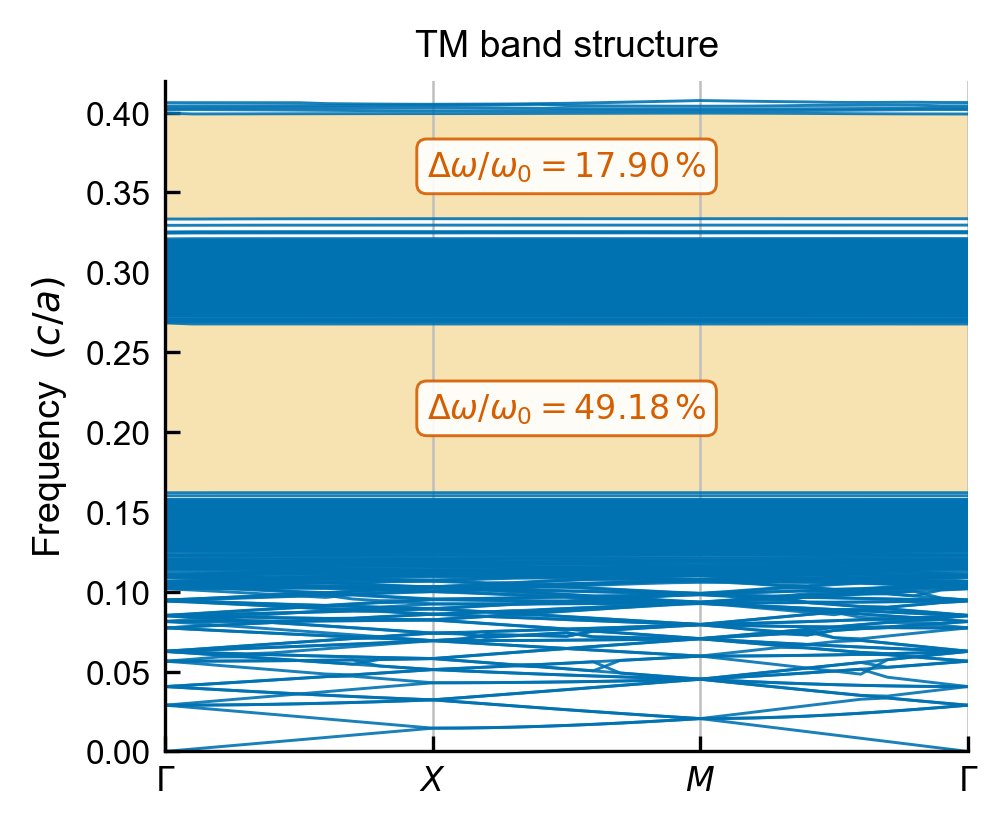

In [10]:
import matplotlib as mpl

# ---- Publication style -------------------------------------------------
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "mathtext.fontset": "dejavusans",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

# Okabe-Ito colorblind-safe palette (deuteranopia/protanopia/tritanopia)
BAND_COLOR = "#0072B2"   # blue       - bands
GAP_COLOR  = "#E69F00"   # orange     - gap shading
GAP_EDGE   = "#D55E00"   # vermillion - annotation box / text

# ---- High-symmetry path ------------------------------------------------
points_in_between = 9
tick_locs = [i * points_in_between + i + 1 for i in range(4)]   # 1, 11, 21, 31
tick_labs = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

# ---- Figure ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=300)

# Draw each band as a continuous line (cleaner than a cloud of points)
for band in freqs.T:
    ax.plot(k_points, band, color=BAND_COLOR, lw=0.7, alpha=0.9)

# Shade band gap(s) and annotate the largest one
gaps = get_gaps(freqs)
for lower, upper, width in gaps:
    ax.axhspan(lower, upper, color=GAP_COLOR, alpha=0.30, lw=0, zorder=0)
    ax.annotate(
        rf"$\Delta\omega/\omega_0 = {width * 100:.2f}\,\%$",
        xy=(k_points.mean(), (lower + upper) / 2),
        ha="center", va="center", fontsize=8, color=GAP_EDGE,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GAP_EDGE, lw=0.7, alpha=0.9),
        zorder=5,
    )

# Vertical separators at high-symmetry points
for x in tick_locs:
    ax.axvline(x, color="0.75", lw=0.6, zorder=0)

# ---- Cosmetics ---------------------------------------------------------
ax.set_xlim(k_points.min(), k_points.max())
ax.set_ylim(0, freqs.max() * 1.03)
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs)
ax.set_ylabel(r"Frequency  $(c/a)$")
ax.set_title("TM band structure", pad=6)
ax.tick_params(top=False, right=False)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

fig.tight_layout()
# fig.savefig("./figures/SHU_TM_band_structure_eps_45.pdf")
plt.show()


In [11]:
gaps

[[0.162002, 0.267659, 0.49181564070278655],
 [0.333584, 0.399156, 0.17897753637033606]]